# Figure 3 and 4: Anomaly propagation

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import cosima_cookbook as cc
from collections import OrderedDict
from dask.distributed import Client
import cftime
import sys
sys.path.append(
    "/g/data/e14/cs6673/Ross_salinity/Python_scripts_published/") 
from Info_definitions import (
    path_data_published, path_plots, exptdict, shelf_mask_isobath)

import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cmocean
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import calendar
import string

In [2]:
plt.rcParams['figure.dpi'] = 96
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 3
plt.rcParams['hatch.color'] = 'k'
plt.rcParams["savefig.facecolor"] = 'white'

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41803/status,
Dashboard: /proxy/41803/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45449,Workers: 7
Dashboard: /proxy/41803/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:44135,Total threads: 4
Dashboard: /proxy/42043/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:46065,


## Load data

In [4]:
# masks for land, shelf, area of wind perturbation and DSW area
ds_bathy = xr.open_dataset(path_data_published + 'Bathymetry_landmask.nc')
ht = ds_bathy.depth
land_mask = ds_bathy.land_mask
mask, shelf_mask = shelf_mask_isobath(land_mask, output_mask=True)


# For Fig 3
ds_salt_map = xr.open_dataset(
    path_data_published + 'Maps_salinity_Ross_Sea.nc', chunks='auto')

ds_salt_hovm = xr.open_dataset(
    path_data_published + 'Hovmoeller_salinity_Ross_Sea.nc', chunks='auto')

# For Fig 4
ds_ssh = xr.open_dataset(
    path_data_published + 'Hovmoeller_ssh_Ross_Sea.nc', chunks='auto')
ds_spd = xr.open_dataset(
    path_data_published + 'Maps_velocity_Ross_Sea.nc', chunks='auto')
ds_rho0_165E = xr.open_dataset(
    path_data_published + 'Section_density_at_165E.nc')
ds_rho0_170W = xr.open_dataset(
    path_data_published + 'Section_density_at_170W.nc')

In [5]:
# Haversine formula for distance between two points on Earth in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radius of the Earth in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c  # Distance in km

In [6]:
# Function to compute cumulative distances along a lat/lon line
def distance_along_line(lat_line, lon_line, return_cum_dist=False):
    # Initialize an array to store the distances
    distances = np.zeros(len(lat_line) - 1)
    
    # Loop over each consecutive pair of points and compute the distance
    for i in range(len(lat_line) - 1):
        distances[i] = haversine(lat_line[i], lon_line[i],
                                 lat_line[i+1], lon_line[i+1])
    
    # Calculate the cumulative distance along the line
    cumulative_distances = np.cumsum(distances)

    if return_cum_dist == True:
        return cumulative_distances
    else:
        return distances

In [7]:
def find_nearest(array, value):
    idx = (np.abs(array - value)).argmin()
    return idx

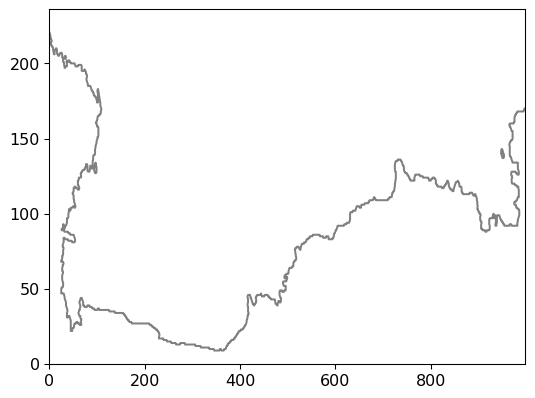

In [8]:
""" Coastal contour"""
coast_land_mask = land_mask.sel(
    yt_ocean=slice(-79, -69), xt_ocean=slice(-200, -100))
xt_ocean = coast_land_mask.xt_ocean
yt_ocean = coast_land_mask.yt_ocean
x_contour = []
y_contour = []

# Create the contour:
cs = plt.contour(coast_land_mask, levels=[0], colors='grey')

for collection in cs.collections:
    for path in collection.get_paths():
        for ii in range(np.size(path.vertices[:, 0])):
            x_contour.append(int(np.round(path.vertices[ii][0])))
            y_contour.append(int(np.round(path.vertices[ii][1])))

lat_contour = np.zeros((len(x_contour)))
lon_contour = np.zeros((len(x_contour)))

for ii in range(len(x_contour)):
    lon_contour[ii] = coast_land_mask.xt_ocean[x_contour[ii]]
    lat_contour[ii] = coast_land_mask.yt_ocean[y_contour[ii]]

# for this coastal contour delete last indices which enclose islands
lat_contour = lat_contour[:-49]
lon_contour = lon_contour[:-49]
dist_contour = distance_along_line(
    lat_contour, lon_contour, return_cum_dist=True)

## Plots

In [9]:
def Fig3(ekeys, time_idx, v_max_map, time_slice, v_max_hovm):
    fig = plt.figure(figsize=(12, 10))
    gs1 = fig.add_gridspec(4, 2,  width_ratios=[1.5, 2], hspace=0.2)
    gs2 = fig.add_gridspec(4, 2,  width_ratios=[1.5, 2], hspace=0.5)

    """ left column: maps """
    ekey = ekeys[0]
    e = exptdict[ekey]
    var_diff = (ds_salt_map['salt_' + ekey] - ds_salt_map['salt_ctrl'])
    proj = ccrs.PlateCarree()

    for i in range(len(time_idx)):
        ax = fig.add_subplot(
            gs1[i, 0],
            projection=ccrs.PlateCarree(central_longitude=185))
        ax.set_extent([160, 265, -79, -70])
        
        ax.contourf(land_mask.xt_ocean, land_mask.yt_ocean,
                    land_mask, colors='silver', levels=[0.5, 2],
                    zorder=2, transform=proj)
        plt.contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask,
                    levels=[0, 1], colors = 'k',  transform=proj)
        gl = ax.gridlines(draw_labels=False)
        gl.xlocator = mticker.FixedLocator(
                [180, -160, -140, -120, -100])
        gl.ylocator = mticker.FixedLocator(
                np.arange(-80, -65, 5))
        ax.set_yticks(np.arange(-80, -65, 5), crs=proj)
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        if i == (len(time_idx)-1):
            ax.set_xticks([180, -140, -100], crs=proj)
            ax.xaxis.set_major_formatter(LongitudeFormatter(
                dateline_direction_label=True))
        plt.ylim(-79, None)
        ax.set_aspect('auto')

        if i == 0:
            # contour of coastline
            plt.plot(lon_contour[:2165], lat_contour[:2165], '.', color='k',
                     markersize=.5, transform=proj)
            for d in np.arange(0, 7000, 1000):
                idx = find_nearest(dist_contour, d)
                plt.plot(lon_contour[idx], lat_contour[idx], 'ok', markersize=6,
                         transform=proj)
                if d == 6000:
                    plt.text(
                        lon_contour[idx]-.2, lat_contour[idx]-.05,
                        str(int(np.round(dist_contour[idx], -2))), va='top',
                        fontsize=10, ha='right', transform=proj)
                else:
                    plt.text(
                        lon_contour[idx]-.2, lat_contour[idx]-.27,
                        str(int(np.round(dist_contour[idx], -2))), va='top',
                        fontsize=10, transform=proj)
        
        if ekey == 'wind_50_down_zonal':
            buffer = -1.2
            ax.plot(
                [e['mask_wind'][0][0]-buffer, e['mask_wind'][0][1]-buffer,
                 e['mask_wind'][0][2], e['mask_wind'][0][3]+buffer,
                 e['mask_wind'][0][4]+buffer, e['mask_wind'][0][5],
                 e['mask_wind'][0][6]-buffer],
                [e['mask_wind'][1][0]-buffer, e['mask_wind'][1][1]+buffer,
                 e['mask_wind'][1][2]+buffer, e['mask_wind'][1][3]+buffer,
                 e['mask_wind'][1][4]-buffer, e['mask_wind'][1][5]-buffer,
                 e['mask_wind'][1][6]-buffer],
                color=e['col'], transform=proj)
        else:
            ax.plot([e['pert_lon'][0], e['pert_lon'][0]], [-79, -69],
                    color=e['col'], transform=proj)
            ax.plot([e['pert_lon'][1], e['pert_lon'][1]], [-79, -69],
                    color=e['col'], transform=proj)
            
        p = ax.pcolormesh(
            var_diff.xt_ocean, var_diff.yt_ocean, var_diff[i, :],
            vmin=-v_max_map, vmax=v_max_map, cmap=cmo.balance,
            transform=proj)
        plt.title(
            string.ascii_lowercase[i] + ') ' + e['expt_str'] + '  -  ' +
            exptdict['ctrl']['expt_str'] + ': ' +
            str(var_diff[i, :].time.dt.day.values) + '. ' +
            calendar.month_name[var_diff[i, :].time.dt.month.values],
            fontweight='bold', loc='left')
        
    pos = ax.get_position()
    cax = plt.axes([pos.xmin, pos.ymin-.08,
                    .8*(pos.xmax-pos.xmin), 0.025])
    cb = plt.colorbar(p, cax=cax, orientation='horizontal', extend='both')
    cb.ax.set_ylabel('g kg$^{-1}$', loc='bottom', labelpad=-210, rotation=0)


    """ right column: Hovmöllers """

    for i, ekey in enumerate(ekeys):
        if i == 0:
            ax = fig.add_subplot(gs2[:2, 1])
        else:
            ax = fig.add_subplot(gs2[2:, 1])
    
        e = exptdict[ekey]
        var = (ds_salt_hovm['salt_' + ekey] - ds_salt_hovm['salt_ctrl'])
    
        time_axis = np.linspace(0, len(var.time)/365, len(var.time))
        pc = ax.pcolormesh(var.distance, time_axis, var, cmap=cmo.balance,
                           vmin=-v_max_hovm, vmax=v_max_hovm)
    
        if ekey == 'wind_50_down_zonal':
            idx = [435, 1235]
        elif (ekey == 'mw_50_down') or (ekey == 'mw_50_down_over_1_yr'):
            idx = [950, ]
        for ii in idx:
            plt.axvline(var.distance[ii], linewidth=2.5, color=e['col'])
        ax.invert_xaxis()
        ax.set_xlabel('Distance (km)', labelpad=2)
        ax.set_ylabel('Model year')
        
        if ekey == 'wind_50_down_zonal':
            dist_e = 2200
            dist_w = 4800
            time_e = 3/365
            time_w = 70/365
        elif ekey == 'mw_50_down':
            dist_e = 2000
            dist_w = 5000
            time_e = 8/365
            time_w = 85/365
        dt = (time_w - time_e) * 365*24*3600 # in s
        ax.plot([dist_e, dist_w], [time_e, time_w], 'grey', linewidth=2.5)
        ax.text(dist_w-10, time_w+15/365,
                 str(np.round(((dist_w-dist_e)*1000/dt), 2)) +
                 r' m s$^{-1}$', color='k').set_bbox(
            dict(facecolor='white', alpha=0.5, linewidth=0, pad=-.8))
                
        ax.set_title(string.ascii_lowercase[i+len(time_idx)] + ') ' +
                     e['expt_str'] + '  -  ' + exptdict['ctrl']['expt_str'],
                     fontweight='bold', loc='left')
    
    pos = ax.get_position()
    cax = plt.axes([pos.xmin, pos.ymin-.08,
                    .8*(pos.xmax-pos.xmin), 0.025])
    cb = plt.colorbar(pc, cax=cax, orientation='horizontal', extend='both')
    cb.ax.set_ylabel('g kg$^{-1}$', loc='bottom', labelpad=-280, rotation=0)
    
    plt.savefig(path_plots + 'Fig3.jpg', dpi=600, bbox_inches="tight")
    plt.show()

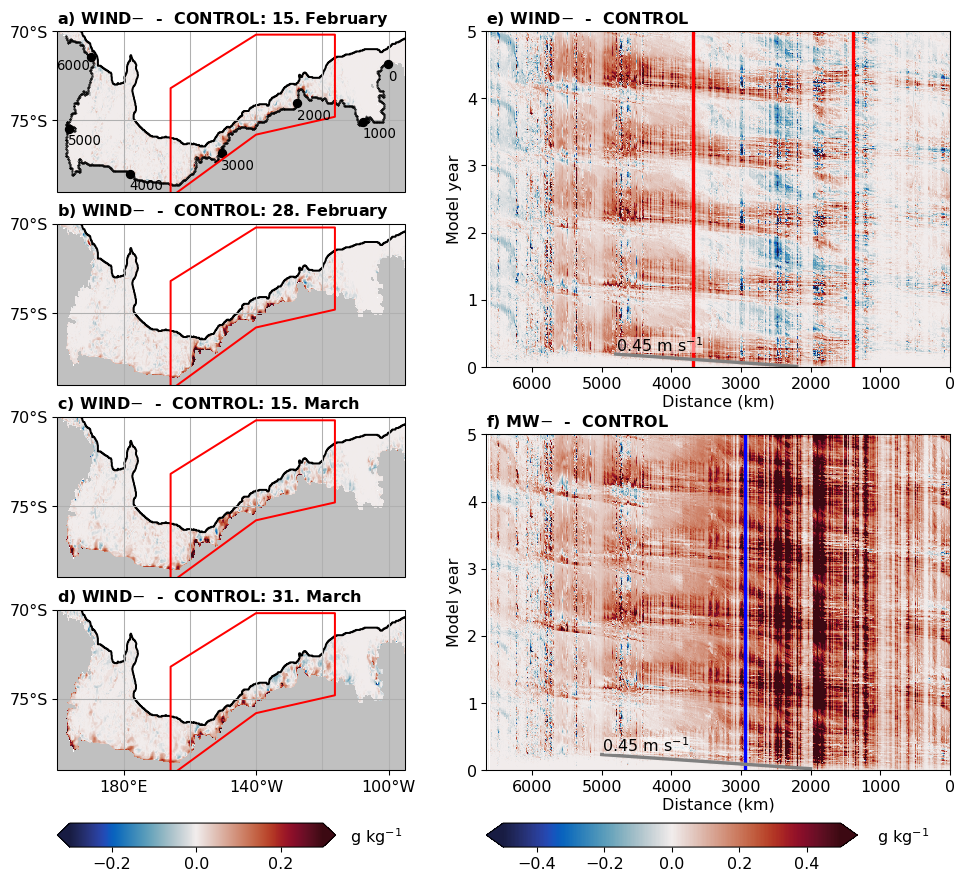

In [10]:
ekeys = ['wind_50_down_zonal', 'mw_50_down']
time_idx = [45, 58, 73, 89]
v_max_map = .3
time_slice = slice('2150', '2154')
v_max_hovm = .5

Fig3(ekeys, time_idx, v_max_map, time_slice, v_max_hovm)

In [11]:
def Fig4(ekey, v_max_ssh, v_max_spd, lon_label, lon, lat,
         c_levels_rho, v_max_rho):

    fig = plt.figure(figsize=(12, 12))
    gs1 = fig.add_gridspec(
        3, 2,  width_ratios=[3, 2], height_ratios=[1, 1, 1.5],
        hspace=0.18, wspace=.2)
    gs2 = fig.add_gridspec(
        3, 2,  width_ratios=[1, 1], height_ratios=[1, 1, 1.5],
        hspace=0.18, wspace=.2)

    e = exptdict[ekey]

    """ a) Hovmöller of daily ssh """
    ssh = ((ds_ssh['ssh_' + ekey] - ds_ssh['ssh_ctrl'])*100)

    fig.add_subplot(gs1[0, 0])
    time_axis = np.arange(len(ssh.time))
    p = plt.pcolormesh(ssh.distance, time_axis, ssh,
                       cmap=cmo.balance, vmin=-v_max_ssh, vmax=v_max_ssh)

    if ekey == 'wind_50_down_zonal':
        idx = [435, 1235]
    elif (ekey == 'mw_50_down') or (ekey == 'mw_50_down_over_1_yr'):
        idx = [950, ]
    for ii in idx:
        plt.axvline(ssh.distance[ii], color=e['col'])
    plt.xlim(5500, 0)
    plt.xlabel('Distance (km)', labelpad=0)
    plt.ylabel('Days', labelpad=6)
    plt.text(.01, .93, string.ascii_lowercase[0] + ') ',
                   fontweight='bold', transform=plt.gca().transAxes)

    pos = plt.gca().get_position()
    cax = plt.axes([pos.xmax+.015, pos.ymin, 0.02, .92*(pos.ymax-pos.ymin)])
    cb = plt.colorbar(p, cax=cax, orientation='vertical', extend='min',
                      ticks=[-5, 0, 5])
    cb.ax.set_title('cm')

    """ b) map of upper ocean velocity """
    fig.add_subplot(gs1[1, 0], projection=ccrs.PlateCarree(central_longitude=185))
    proj = ccrs.PlateCarree()
    
    u_diff = (ds_spd['u_' + ekey] - ds_spd['u_ctrl'])*100 # in cm/s
    v_diff = (ds_spd['v_' + ekey] - ds_spd['v_ctrl'])*100 # in cm/s
    spd = np.sqrt(ds_spd['u_' + ekey]**2 + ds_spd['v_' + ekey]**2)
    spd_ctrl = np.sqrt(ds_spd['u_ctrl']**2 + ds_spd['v_ctrl']**2)
    spd_diff = (spd - spd_ctrl)*100 # in cm/s
    coars_x = 20
    coars_y = 8
    u_diff_coars = u_diff.coarsen(xu_ocean=coars_x, boundary='trim').mean(
        ).coarsen(yu_ocean=coars_y, boundary='trim').mean()
    v_diff_coars = v_diff.coarsen(xu_ocean=coars_x, boundary='trim').mean(
        ).coarsen(yu_ocean=coars_y, boundary='trim').mean()

    ax = plt.gca()
    ax.set_extent([160, 255, -79, -72])
    ax.contourf(land_mask.xt_ocean, land_mask.yt_ocean,
                land_mask, colors='silver', levels=[0.5, 2],
                zorder=2, transform=proj)
    gl = ax.gridlines(draw_labels=False)
    gl.xlocator = mticker.FixedLocator(
        [180, -160, -140, -120])
    ax.set_xticks([180, -160, -140, -120], crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter(
        dateline_direction_label=True))
    gl.ylocator = mticker.FixedLocator([-78, -75, -72])
    ax.set_yticks([-78, -75, -72], crs=proj)
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.set_ylim(-79, None)
    ax.set_aspect('auto')

    # contour of coastline
    ax.plot(lon_contour[:1890], lat_contour[:1890], '.', color='k',
            markersize=1, transform=proj)
    for d in np.arange(1000, 6000, 1000):
        idx = find_nearest(dist_contour, d)
        ax.plot(lon_contour[idx], lat_contour[idx], 'ok',
                markersize=6, transform=proj)
        if (d == 1000) or (d == 4000):
            ax.text(lon_contour[idx]-.2, lat_contour[idx]-.15,
                    str(int(np.round(dist_contour[idx], -2))),
                    va='top', ha='right', transform=proj)
        else:
            ax.text(lon_contour[idx], lat_contour[idx]-.15,
                    str(int(np.round(dist_contour[idx], -2))),
                    va='top', transform=proj)
    for l in range(len(lon)):
        ax.plot([lon[l], lon[l]], [lat[l].start, lat[l].stop], color='magenta',
                transform=proj)
    
    if ekey == 'wind_50_down_zonal':
        buffer = -1.2
        ax.plot([e['mask_wind'][0][0]-buffer, e['mask_wind'][0][1]-buffer,
                 e['mask_wind'][0][2], e['mask_wind'][0][3]+buffer,
                 e['mask_wind'][0][4]+buffer, e['mask_wind'][0][5],
                 e['mask_wind'][0][6]-buffer],
                [e['mask_wind'][1][0]-buffer, e['mask_wind'][1][1]+buffer,
                 e['mask_wind'][1][2]+buffer, e['mask_wind'][1][3]+buffer,
                 e['mask_wind'][1][4]-buffer, e['mask_wind'][1][5]-buffer,
                 e['mask_wind'][1][6]-buffer],
                color=e['col'], transform=proj)
    else:
        ax.plot([e['pert_lon'][0], e['pert_lon'][0]], [-79, -69],
                color=e['col'], transform=proj)
        ax.plot([e['pert_lon'][1], e['pert_lon'][1]], [-79, -69],
                color=e['col'], transform=proj)

    p = ax.pcolormesh(
        spd_diff.xu_ocean, spd_diff.yu_ocean, spd_diff,
        vmin=-v_max_spd, vmax=v_max_spd, cmap=cmo.balance, transform=proj)
    ax.text(.01, .93, string.ascii_lowercase[1] + ') ',
            fontweight='bold', transform=plt.gca().transAxes)

    qr = ax.quiver(u_diff_coars.xu_ocean, u_diff_coars.yu_ocean,
                   u_diff_coars.values, v_diff_coars.values,
                   scale=150, width=0.003, transform=proj)

    pos = ax.get_position()
    cax = plt.axes([pos.xmax+.015, pos.ymin, 0.02, .93*(pos.ymax-pos.ymin)])
    cb = plt.colorbar(p, cax=cax, orientation='vertical', extend='both')
    cb.ax.set_title(r'cm s$^{-1}$', x=1.2)

    """ c + e) sections of rho """
    cmap_mod =  cmocean.tools.crop_by_percent(
        cmo.balance, 15, which='both', N=None)

    ds_section =  [ds_rho0_165E, ds_rho0_170W]
    for l in range(len(lon_label)):
        var_section_ctrl = ds_section[l]['rho0_' + lon_label[l] + '_ctrl']
        var_section = ds_section[l]['rho0_' + lon_label[l] + '_' + ekey]

        fig.add_subplot(gs2[2, l])
        cs = plt.contour(var_section.yt_ocean, var_section.st_ocean,
                         var_section_ctrl, levels=c_levels_rho[l], colors='k')
        plt.clabel(cs, inline=True, use_clabeltext=True, colors='k',
                   fmt='%1.2f', fontsize=10)
        plt.contour(var_section.yt_ocean, var_section.st_ocean,
                    var_section, levels=c_levels_rho[l], colors=e['col'])
        var_section = var_section - var_section_ctrl
        pp = plt.pcolormesh(
            var_section.yt_ocean, var_section.st_ocean, var_section,
            cmap=cmap_mod, vmin=-v_max_rho, vmax=v_max_rho)
        plt.xlabel('Latitude')
        if l == 0:
            plt.ylabel('Depth (m)', labelpad=1)
        else:
            plt.gca().set_yticklabels([])
        plt.text(.02, .93, string.ascii_lowercase[l*2+2] + ') ',
                 fontweight='bold', transform=plt.gca().transAxes)
        if lon[l] < -180:
            lon_str = str(lon[l]+360) + '°E'
        elif lon[l] < 0:
            lon_str = str(np.abs(lon[l])) + '°W'
        plt.text(.02, .02, lon_str, fontweight='bold',
                 transform=plt.gca().transAxes)
        plt.gca().invert_yaxis()
        plt.gca().xaxis.set_major_formatter(LatitudeFormatter())
    
    pos = plt.gca().get_position()
    cax = plt.axes([pos.xmax+.015, pos.ymin, 0.02, .93*(pos.ymax-pos.ymin)])
    cb = plt.colorbar(pp, cax=cax, orientation='vertical', extend='both')
    cb.ax.set_title('kg m$^{-3}$', x=1.3)

    plt.savefig(path_plots + 'Fig4_wo_schematic.jpg', dpi=600, bbox_inches="tight")
    plt.show()

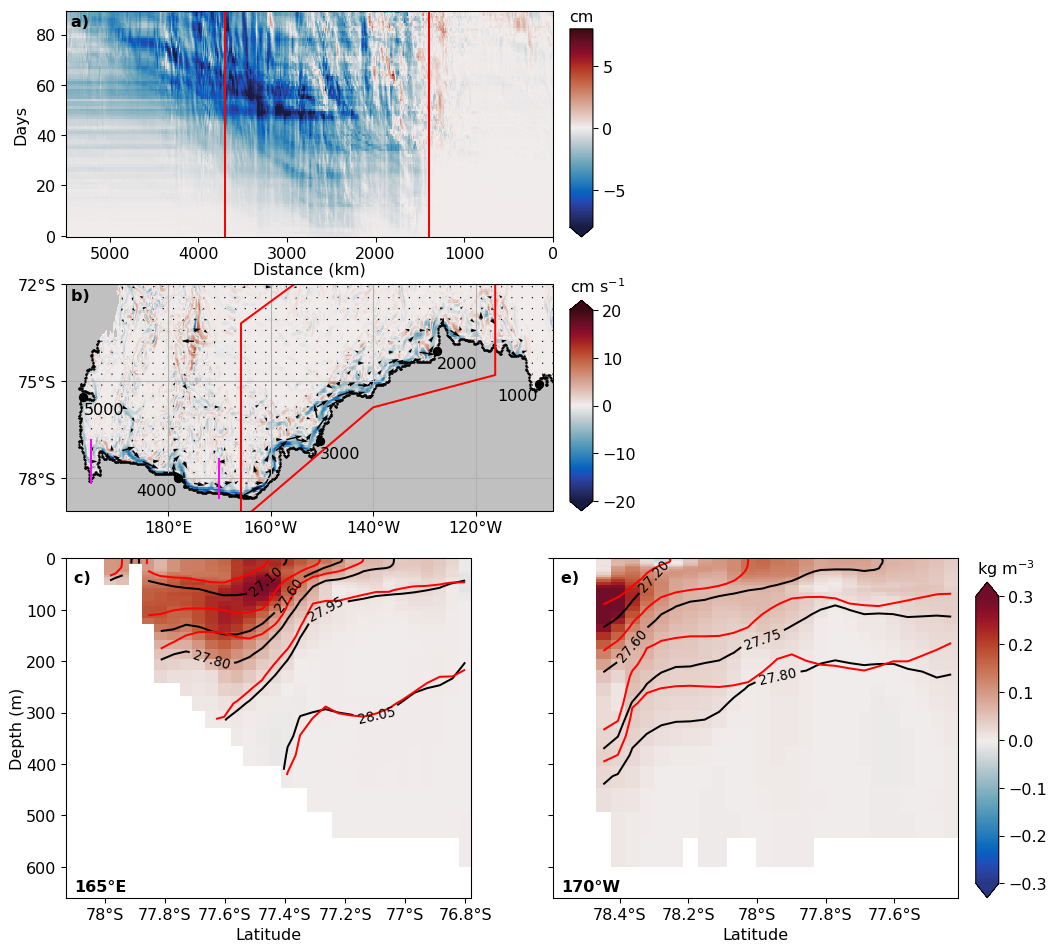

In [12]:
ekey = 'wind_50_down_zonal'
v_max_ssh = 8
v_max_spd = 20 
lon_label = ['165E', '170W']
lon = [-195, -170]  # 165E, 170W
lat = [slice(-78.15, -76.8), slice(-78.6, -77.4)]
c_levels_rho = [[27.1, 27.6, 27.8, 27.95, 28.05],
                [27.2, 27.6, 27.75, 27.8]]
v_max_rho = .3

Fig4(ekey, v_max_ssh, v_max_spd, lon_label, lon, lat, c_levels_rho, v_max_rho)